# Smoothing Images

## Kernel Convolution

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [3]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [2]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [5]:
img

array([[2, 4, 2, 5, 0, 3, 6, 7, 4, 3, 7, 2],
       [6, 0, 9, 7, 4, 5, 3, 1, 0, 5, 2, 5],
       [0, 5, 3, 2, 1, 8, 7, 4, 9, 8, 0, 7],
       [8, 3, 7, 2, 0, 9, 8, 2, 4, 2, 8, 3],
       [0, 6, 4, 1, 7, 7, 2, 1, 7, 7, 9, 9],
       [6, 8, 9, 0, 4, 5, 2, 5, 3, 5, 8, 0],
       [7, 9, 0, 3, 5, 1, 7, 1, 4, 6, 3, 6],
       [1, 1, 3, 9, 8, 6, 8, 7, 1, 9, 3, 6],
       [1, 1, 1, 4, 3, 4, 5, 8, 2, 9, 7, 3],
       [1, 5, 5, 4, 9, 9, 5, 6, 8, 6, 8, 1],
       [0, 6, 3, 6, 6, 1, 0, 8, 9, 3, 4, 2],
       [0, 5, 1, 9, 8, 5, 9, 8, 6, 0, 1, 6]])

In [6]:
h,w=img.shape

In [7]:
print(h,w)

12 12


In [8]:
#[*range(-2,3)]

In [12]:
dst = np.zeros((h,w),int)

In [15]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [16]:
img

array([[2, 4, 2, 5, 0, 3, 6, 7, 4, 3, 7, 2],
       [6, 0, 9, 7, 4, 5, 3, 1, 0, 5, 2, 5],
       [0, 5, 3, 2, 1, 8, 7, 4, 9, 8, 0, 7],
       [8, 3, 7, 2, 0, 9, 8, 2, 4, 2, 8, 3],
       [0, 6, 4, 1, 7, 7, 2, 1, 7, 7, 9, 9],
       [6, 8, 9, 0, 4, 5, 2, 5, 3, 5, 8, 0],
       [7, 9, 0, 3, 5, 1, 7, 1, 4, 6, 3, 6],
       [1, 1, 3, 9, 8, 6, 8, 7, 1, 9, 3, 6],
       [1, 1, 1, 4, 3, 4, 5, 8, 2, 9, 7, 3],
       [1, 5, 5, 4, 9, 9, 5, 6, 8, 6, 8, 1],
       [0, 6, 3, 6, 6, 1, 0, 8, 9, 3, 4, 2],
       [0, 5, 1, 9, 8, 5, 9, 8, 6, 0, 1, 6]])

In [17]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, -24,  24,   8,   3,   2,  -7, -10, -19,   7,  -9,   0],
       [  0,  14, -11,  -5, -10,  10,   5,  -3,  20,  16, -25,   0],
       [  0, -14,  16,  -2, -19,  13,  12,  -9,  -4, -19,  18,   0],
       [  0,   9,  -7,  -9,  16,   5, -10, -12,  13,   5,   4,   0],
       [  0,   2,  24, -17,  -1,   6, -11,  13,  -9,  -4,  15,   0],
       [  0,  20, -24,  -2,   4, -19,  16, -19,   5,   3, -11,   0],
       [  0, -10,   1,  18,   9,   3,   7,  10, -18,  17, -13,   0],
       [  0,  -4,  -9,  -1, -13,  -7,  -5,  12, -18,  12,   5,   0],
       [  0,   7,   7,  -8,  14,  17,   0,  -5,   9,  -4,  14,   0],
       [  0,  11,  -6,   2,   0, -16, -23,   9,  11,  -7,   2,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [3]:
img = cv2.imread('lena.png', 0)

In [4]:
h,w=img.shape

In [20]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [21]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [ ]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

: 

In [6]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

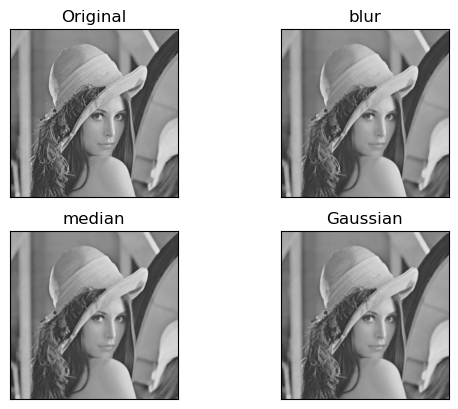

In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
blur = cv2.bilateralFilter(img1,9,75,75)
median = cv2.medianBlur(img1,5)
Gaussian = cv2.GaussianBlur(img1,(5,5),0)
plt.subplot(221),plt.imshow(img1)
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(222),plt.imshow(blur)
plt.title('blur'), plt.xticks([]), plt.yticks([])
plt.subplot(223),plt.imshow(median)
plt.title('median'), plt.xticks([]), plt.yticks([])
plt.subplot(224),plt.imshow(Gaussian)
plt.title('Gaussian'), plt.xticks([]), plt.yticks([])
plt.show()